# Exploratory Data Analysis

## Objectives
- Understand customer demographics
- Identify churn patterns
- Detect outliers
- Discover relationships between features
- Generate insights for feature engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# This hides annoying red warning texts that don't affect our code
warnings.filterwarnings("ignore")

# This forces pandas to show every single column instead of hiding them with "..."
pd.set_option("display.max_columns", None)

# Loading the data set 

In [3]:
df = pd.read_csv('../data/bank_churn.csv')

## 1.1 Structural Inspection & Data Validation

### Objective
To load the raw banking data and validate its dimensions, data types, and initial memory footprint before beginning statistical analysis.

### Business & Data Science Justification
Before building a churn prediction model, we must confirm the integrity of the database export. This step ensures we have the expected volume of customer records and identifies any immediate parsing errors (e.g., numeric features incorrectly loaded as text). Understanding our categorical vs. numerical feature space dictates our preprocessing strategy later in the pipeline.

In [4]:
# 2. Check the dimensions of the dataframe
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

# 3. Output structural metadata (dtypes, non-null counts)
df.info()

# 4. Inspect the first 5 rows visually
display(df.head())

Dataset Shape: 10000 rows and 12 columns

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1.1 Interpretation & Next Steps
* **Dimensions:** The dataset contains 10,000 records and 12 features.
* **Data Types:** All columns parsed successfully as either numeric (`int64`, `float64`) or text (`str`). **Anomaly Note:** `customer_id` is loaded as an `int64`, but it is an identifier, not a mathematical value, so it must be excluded from modeling. Additionally, `credit_card`, `active_member`, and `churn` are binary flags (0 or 1) currently stored as 64-bit integers; downcasting these later could optimize memory.
* **Missing Values:** There are 0 missing values. Every feature contains exactly 10,000 non-null entries, indicating a highly complete dataset.

## 1.2 Descriptive Statistics

### Objective
To calculate statistical summaries of the dataset to identify distributions, detect potential outliers, and evaluate feature scaling requirements.

### Rationale
Understanding the central tendency (mean, median) and dispersion (standard deviation, min/max) of numerical features highlights extreme values that could skew predictive models. Evaluating categorical features allows us to understand class frequencies and cardinality, guiding our encoding strategy.

In [5]:
# 1. Summary statistics for numerical features (math)
print("--- Numerical Features Summary ---")
display(df.describe())

# 2. Summary statistics for categorical features (text)
# The 'include=["object"]' parameter forces pandas to evaluate string columns
print("\n--- Categorical Features Summary ---")
display(df.describe(include=['object']))

--- Numerical Features Summary ---


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



--- Categorical Features Summary ---


,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


### 1.3 Univariate Analysis: Categorical Features & Target Variable
Visualizing the frequency distribution of categorical features to assess demographic concentrations and explicitly plotting the target variable (`churn`) to evaluate class imbalance.

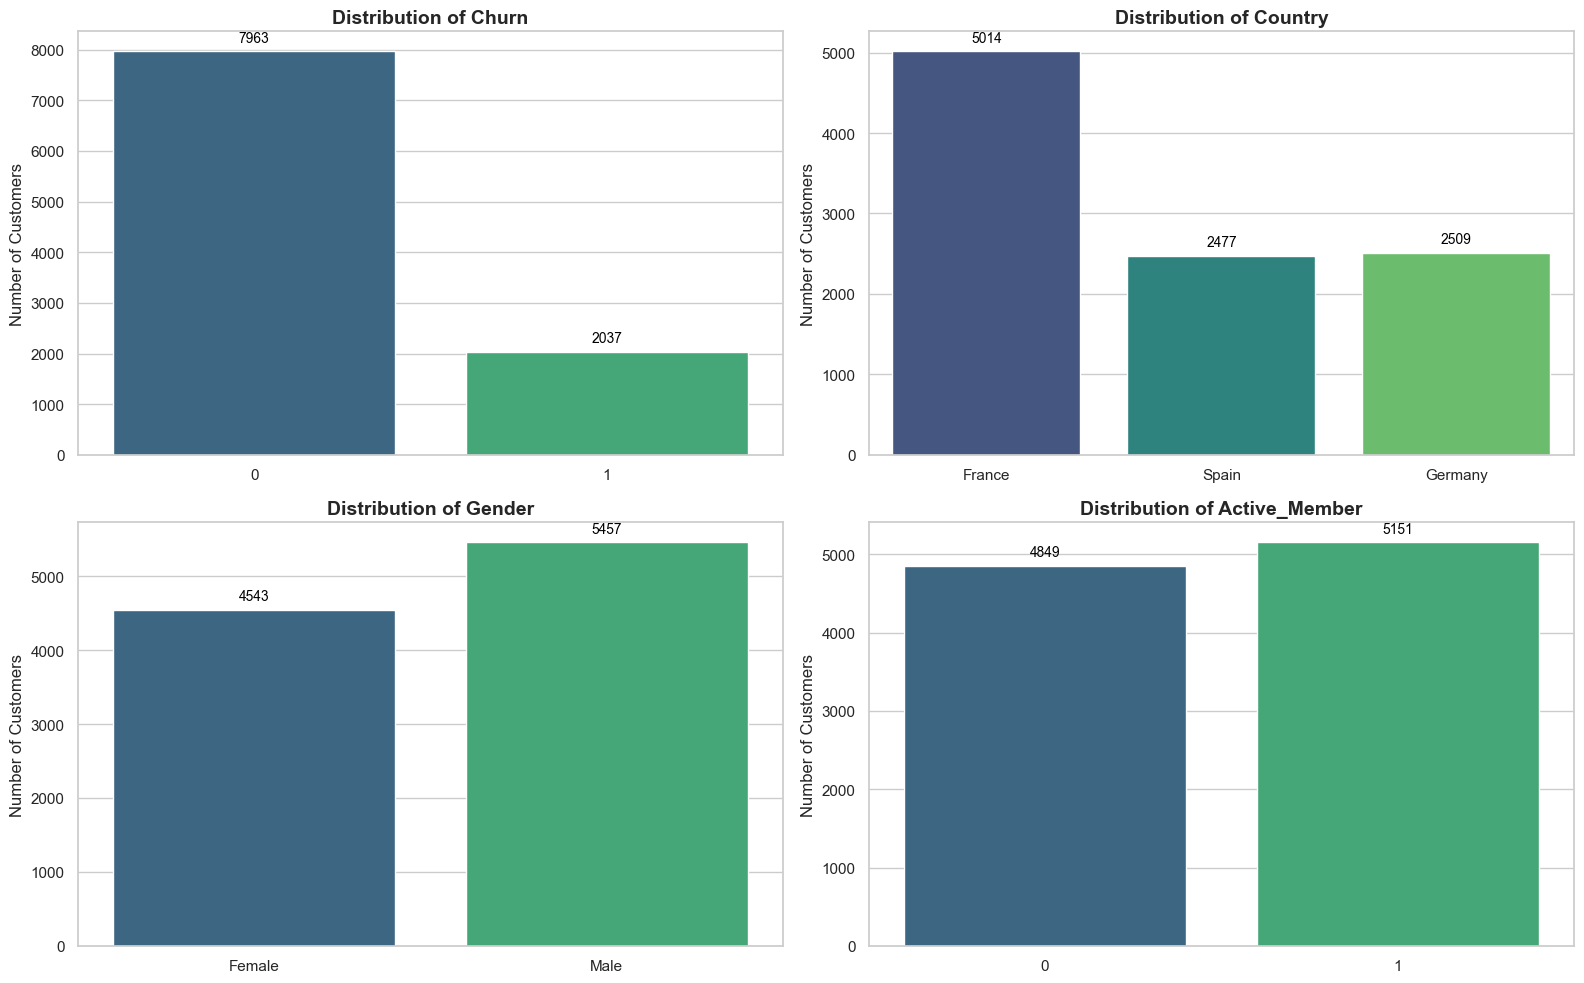

In [6]:
# Set up a professional figure aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Define the categorical features we want to visualize
categorical_features = ['churn', 'country', 'gender', 'active_member']

# Create a 2x2 grid of subplots
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    
    # Create the bar chart (countplot)
    ax = sns.countplot(data=df, x=feature, palette='viridis', hue=feature, legend=False)
    
    # Add a title and tweak labels for professionalism
    plt.title(f'Distribution of {feature.title()}', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Customers')
    plt.xlabel('')
    
    # Add data labels on top of the bars for precision
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

### 1.4 Bivariate Analysis
Analyzing the relationship between key independent features (Geography, Age) and the target variable (Churn) to identify distinct patterns and preliminary feature importance.

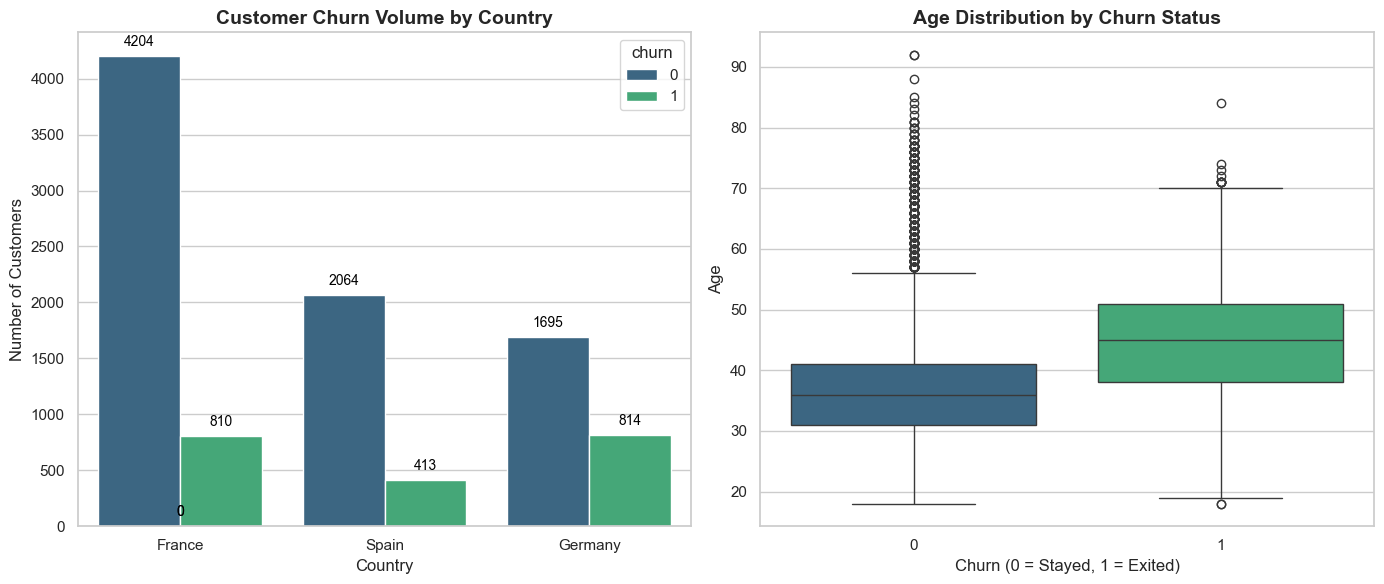

In [7]:
# Set up a professional figure aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Categorical vs Target: Country vs Churn
plt.subplot(1, 2, 1)
# Using hue='churn' splits the bars by who stayed and who left
ax1 = sns.countplot(data=df, x='country', hue='churn', palette='viridis')
plt.title('Customer Churn Volume by Country', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Country')

# Add data labels for precision
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', 
                 fontsize=10, color='black', xytext=(0, 5), 
                 textcoords='offset points')

# 2. Numerical vs Target: Age vs Churn
plt.subplot(1, 2, 2)
# A boxplot perfectly shows the mathematical distribution of age for both groups
sns.boxplot(data=df, x='churn', y='age', palette='viridis')
plt.title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.ylabel('Age')
plt.xlabel('Churn (0 = Stayed, 1 = Exited)')

plt.tight_layout()
plt.show()